# **Legend**

The "Cunning Fox" chain of stores is exclusively engaged in the sale of fisstech (spices) in several cities (Novigrad, Oxenfurt, and others).

Six months ago, "Cunning Fox" conducted a marketing campaign. Some clients received letters via crows with a personalized offer: "Hurry to get a discount of 40 orens on your first purchase of one gram of fisstech.

The discount is valid for a week." The former marketer of "Cunning Fox" didn't think long and chose the audience for communication randomly.

Your task is to select a portion of "Cunning Fox" clients so that the total profit (definition in the evaluation section) from the campaign with such an offer is maximized. The solution will be a list of selected clients.

There is no need to allocate a control group - the necessary procedures for evaluating the solution will be carried out in the system.

You have at your disposal information on sales for the last 250 days, basic information about customers, and the history of launched campaigns.

  **Important to know:**

* The price of 1 gram of fisstech is 80 orens.


* The cost price is 52 orens.

* Sending one message via crow costs 1 oren.

* "Cunning Fox" has a competitor 😉 - the "Seven Cats" tavern chain, which also sells fisstech.


Data description:

* customers.csv - customers description
    ```
    customer_id - ID
    age - age
    location - customer's place of residence
    ```
* receipts.parquet - purchase history
    ```
    customer_id - ID
    date - purchase date
    purchase_amt - fisstech amount (gramms)
    purchase_sum - purchase amount (orens)
    ```
* campaigns.csv - campaign history
    ```
    customer_id - ID
    date - discount first day
    n_offer_days - discount period in days
    target_group_flag - target (1) / control (0) group flag
    ```

In [1]:
!pip install pylift
!pip install causalml

from google.colab import drive
import numpy as np, pandas as pd, sys, os

from matplotlib import ticker
import matplotlib.pyplot as plt, seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
from IPython.display import display, clear_output

import pylift

from typing import List, Union, Optional, Dict
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)
pd.set_option('display.float_format', '{:.4f}'.format)
from collections.abc import Iterable
import gc

def is_iterable(obj):
    return isinstance(obj, Iterable)

drive.mount('/content/drive')
DIR = Path('/content/drive/MyDrive/Colab Notebooks/Машинное обучение/uplift/project_uplift/')

CUSTOMERS = DIR/'data'/'customers.csv'
RECEIPTS = DIR/'data'/'receipts.parquet'
CAMPAIGNS = DIR/'data'/'campaigns.csv'

clear_output()

### EDA

In [2]:
campaign_data = (pd.read_csv(CAMPAIGNS).drop(columns='Unnamed: 0')
                   .assign(date_to = lambda x: x['date'] + x['n_offer_days'])
                   .assign(date_from = lambda x: x['date'])
                   .drop(columns=['date'])
)
display(campaign_data.head())
campaign_data.info()
# how many days was campaign? how many campaigns was?
campaign_data.groupby(['n_offer_days', 'date_from', 'target_group_flag']).agg({'customer_id':'count'})

,customer_id,n_offer_days,target_group_flag,date_to,date_from
0,0,7,1,109,102
1,1,7,1,109,102
2,2,7,1,109,102
3,3,7,1,109,102
4,4,7,1,109,102


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   customer_id        500000 non-null  int64
 1   n_offer_days       500000 non-null  int64
 2   target_group_flag  500000 non-null  int64
 3   date_to            500000 non-null  int64
 4   date_from          500000 non-null  int64
dtypes: int64(5)
memory usage: 19.1 MB


,,,customer_id
n_offer_days,date_from,target_group_flag,
7,102,1,500000


,customer_id,age,location
0,0,56,Oxenfurt
1,1,53,Hindarsfjall
2,2,41,Hindarsfjall
3,3,60,Kaer_Trolde
4,4,22,Spikeroog


<Axes: xlabel='age', ylabel='Count'>

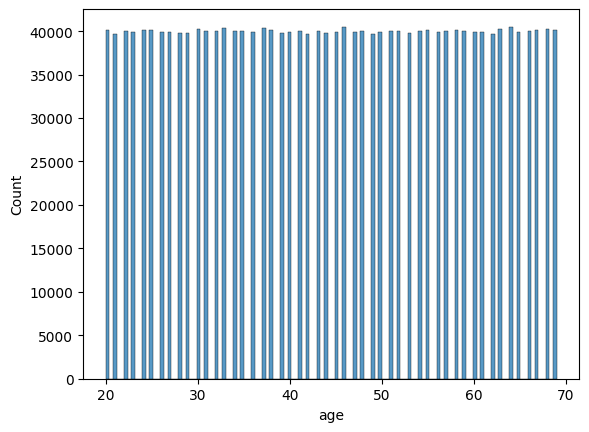

In [3]:
# plot customers age distribution
customers_data = pd.read_csv(CUSTOMERS).drop(columns='Unnamed: 0')
display(customers_data.head(5))
sns.histplot(customers_data['age'])

In [4]:
# show receipts data
receipts_data = (pd.read_parquet(RECEIPTS)
                   .merge(campaign_data, on=['customer_id'], how='left')
                   .assign(target_group_flag = lambda x: np.where(x['date'].between(x['date_from'], x['date_to']),1,0 ))
                   .assign(campaign_flag = lambda x: np.where(x['date'].between(x['date_from'].min(), x['date_to'].min()), 1, 0))
                   .merge(customers_data, on='customer_id', how = 'left')
                   .drop(columns=['n_offer_days', 'date_to', 'date_from'])
)
display(receipts_data.head())
receipts_data.groupby(['target_group_flag', 'date']).agg({'customer_id':'count'})

,customer_id,date,purchase_amt,discount,purchase_sum,target_group_flag,campaign_flag,age,location
0,26,0,12.1253,0,970.0219,0,0,66,Oxenfurt
1,53,0,34.3570,0,2748.5628,0,0,31,Hindarsfjall
2,56,0,8.6958,0,695.6660,0,0,60,Hindarsfjall
3,58,0,28.2990,0,2263.9236,0,0,37,Oxenfurt
4,64,0,32.5475,0,2603.8009,0,0,46,Hindarsfjall


customer_id
target_group_flag date             
0                 0          126350
                  1          126556
                  2          126401
                  3          125970
                  4          126396
...                             ...
1                 105         35493
                  106         34803
                  107         34506
                  108         34480
                  109         31175

[258 rows x 1 columns]

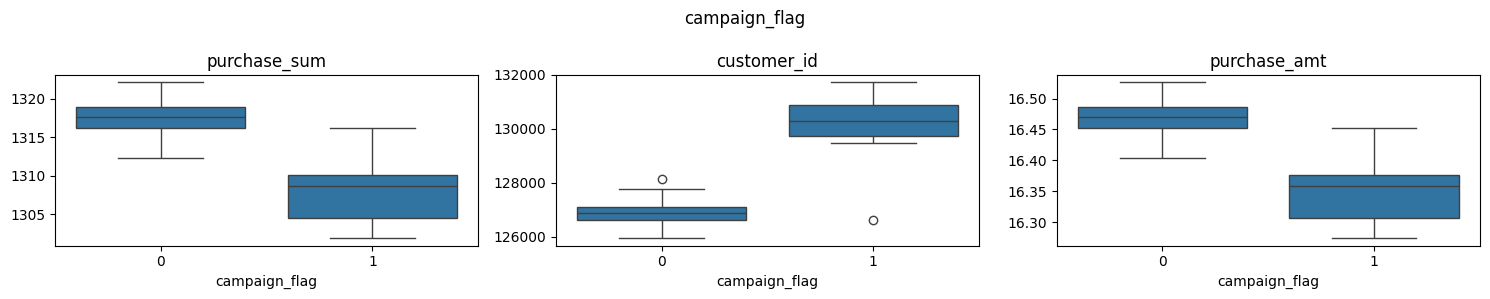

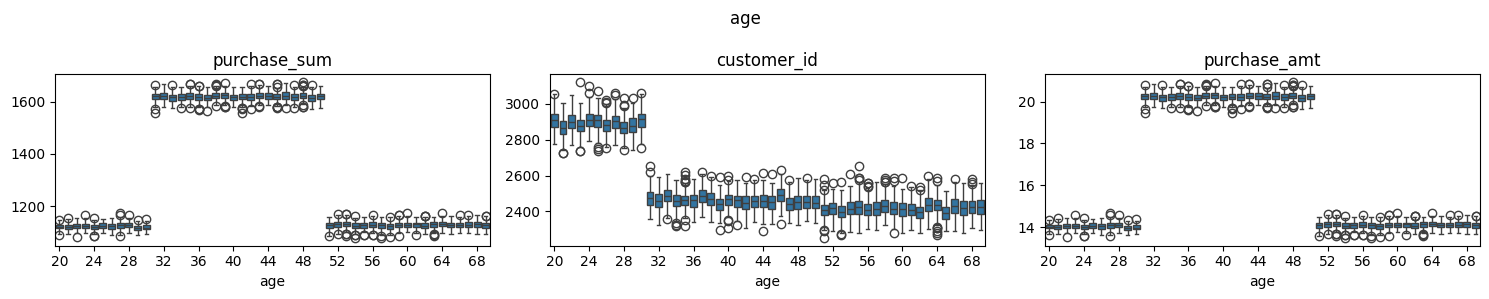

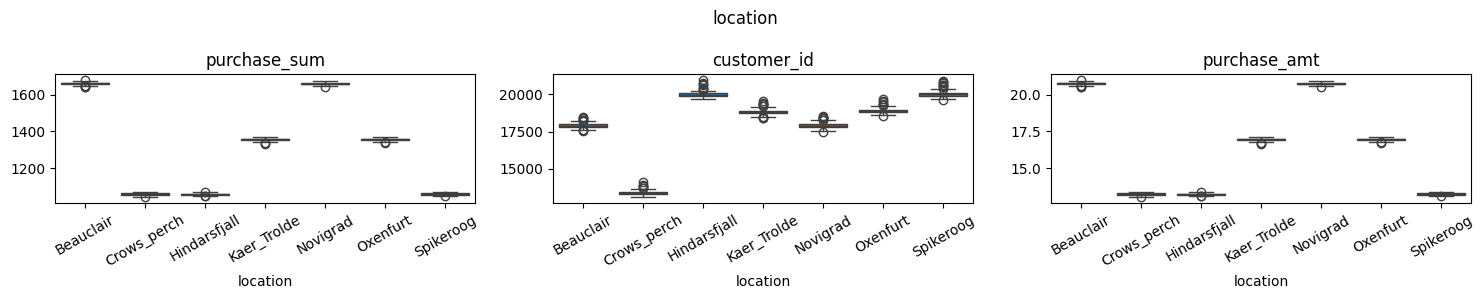

In [5]:
# plot boxplot distribution key performance metric by each regular feature and treatment flag
MAX_TICKS = 15
for drill in ['campaign_flag', 'age', 'location']:
  GB = [drill, 'date']
  AGG = {'purchase_sum': 'mean',
         'customer_id':'count',
         'purchase_amt':'mean'}
  df_plot = (receipts_data.groupby(GB)
                          .agg(AGG)
                          .reset_index()
                          .sort_values(GB) )

  fig, axes = plt.subplots(1,3, figsize=(15,3))
  axes = iter(axes.flatten())
  metrics = iter(AGG.keys())

  for i in  range(len(AGG)):
    ax = next(axes)
    metric = next(metrics)
    sns.boxplot(data=df_plot, x=drill, y=metric, ax=ax)

    ax.set_title(metric)#, ax.set_yscale('log')
    ax.set_ylabel('')
    if df_plot[drill].nunique() > MAX_TICKS:
      ax.xaxis.set_major_locator(ticker.MaxNLocator(MAX_TICKS))
    if drill in {'location'}:
      ax.xaxis.set_major_locator(ticker.FixedLocator(ax.get_xticks()))
      ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

  plt.suptitle(drill), plt.tight_layout()
  plt.show()

### Feature Engeneering

In [6]:
# spark initialisation
%cd {str(DIR)}
import spark_init
from pyspark.sql import SparkSession, functions as f, Window
from pyspark.sql.types import StringType, StructField, StructType, ArrayType, FloatType, DoubleType
from pyspark.ml.feature import Bucketizer
from pyspark.ml.feature import StringIndexer, OneHotEncoder
import pyspark

appName = "FNI"
driverMemory = "3g"
driverCores = "5"
executorCores = "5"
executorMemory = "2g"
maxExecutors = "2"
memoryOverhead = "1g"

spark = (SparkSession.builder
                     .appName(appName)
                     .config('spark.ui.port', '4040')
                     .config("spark.driver.memory", driverMemory)
                     .config("spark.driver.cores", driverCores)
                     .config("spark.executor.memory", executorMemory)
                     .config("spark.executor.cores", executorCores)
                     .config("spark.executor.instances", maxExecutors)
                     .config("spark.executor.memoryOverhead", memoryOverhead)
                     .config("spark.sql.autoBroadcastJoinThreshold", "-1")
                     .config("spark.sql.execution.arrow.pyspark.enabled", "true")
).getOrCreate()

def garbage_collect():
  gc.collect()
  spark.catalog.clearCache()
# show spark session
spark

/content/drive/MyDrive/Colab Notebooks/Машинное обучение/uplift/project_uplift


In [7]:
# CONSTANTS
price = 80
cost = 52
message_cost = 1

# load campaign data
campaign_spark = (spark.read.csv(str(CAMPAIGNS), header=True)
                       .withColumn('target_group_flag', f.col('target_group_flag').astype('int'))
                       .withColumn('date_to', f.col('date') + f.col('n_offer_days'))
                       .withColumn('date_from', f.col('date'))
                       .drop('date', '_c0'))


# load customers data
customers_spark = spark.read.csv(str(CUSTOMERS), header=True).drop('_c0')

# calculate start and end campaign dates
START_CAMPAIGN = int(campaign_spark.agg({'date_from': 'min'}).collect()[0][0])
END_CAMPAIGN = int(campaign_spark.agg({'date_to': 'max'}).collect()[0][0])

# load receipts raw data
receipts_spark = (spark.read.parquet(str(RECEIPTS))
                       .join(campaign_spark.selectExpr('customer_id', 'target_group_flag', 'date_from AS date'), on=['customer_id', 'date'], how='left')
                       .fillna(0, subset=['target_group_flag'])
                       .withColumn('campaign_flag', f.when((f.col('date') >= START_CAMPAIGN) &
                                                           (f.col('date') <= END_CAMPAIGN), 1).otherwise(0))

                       .withColumn('discount_sum', f.col('discount'))
                       .join(customers_spark, on='customer_id', how='left')
                       .drop('n_offer_days', 'date_to', 'date_from', '__index_level_0__'))

In [8]:
# backward features calculator
class BackwardCalcer():
  def __init__(self,
               target_date,
               metrics = ['purchase_sum', 'date'],
               group_columns = 'customer_id',
               date_column = 'date',
               windows=[5,100],
               agg_func=['sum', 'mean', 'count', 'max', 'min'],
               verbose = True,
               ) -> None:
    self.metrics = metrics
    self.group_columns = group_columns
    self.date_column = date_column
    self.target_date = target_date
    self.windows = windows
    self.agg_func = agg_func
    self.verbose = verbose
    self.query = self.query_builder()
    self.features = None
    pass

  def query_builder(self):
    QUERY = []
    for window in self.windows: # for each time window
      for metric in self.metrics: # for each feature
        for func in self.agg_func: # look back and calculate aggregation function
          func_spark = getattr(f, func) # get spark function
          alias = metric + f'_{func}_' + str(window) + 'd' # set alias
          if func != 'count' and (metric != self.date_column or (metric == self.date_column and func in ['min','max'])): # min max func for date feature and ignore count func
            q = func_spark(f.when(f.col(self.date_column).between(self.target_date - window, self.target_date), f.col(metric))).alias(alias) # set spark calculation
            QUERY.append(q) # add to list

      if 'count' in self.agg_func: # reduce count duplication for each metric
        alias = 'count_' + str(window) + 'd'
        q = f.count(f.when(f.col(self.date_column).between(self.target_date - window, self.target_date), f.col(self.date_column))).alias(alias)
        QUERY.append(q)

    if self.verbose: display(QUERY)
    return QUERY

  def fit_transform(self, df):
    return self.fit(df).transform(df)

  def fit(self, df):
    return self

  def transform(self, df):
    # use aggregation query in look back time window
    result = (df.filter(f.col(self.date_column) < self.target_date)
                .groupby(self.group_columns)
                .agg(*self.query)
                .fillna(0))
    # calculate date related feature
    if self.date_column in self.metrics:
      for window in self.windows:
        metric = self.date_column
        alias = 'mean_time_interval_' + str(window) + 'd'
        result = result.withColumn(alias, ((f.col(f'{metric}_max_{window}d') - f.col(f'{metric}_min_{window}d')) / (f.col(f'count_{window}d') - 1)))

        alias = 'time_scince_last_' + str(window) + 'd'
        result = result.withColumn(alias, (self.target_date - f.col(f'{metric}_max_{window}d')))

    self.features = result.columns
    self.features.remove(self.group_columns)

    return result

In [9]:
# one hot encoder
class Encoder():
  def __init__(self, columns) -> None:
    self.string_indexer = {}
    self.one_hot_encoder = {}
    self.categories = {}
    self.columns = None
    self.vector_to_array_udf = f.udf(Encoder._vector_to_array, ArrayType(DoubleType()))
    self.prefix_1 = '_indexer'
    self.prefix_2 = '_encoder'
    if type(columns) is str:
      columns = [columns]
    self.columns = columns
    self.features = []
    pass

  @staticmethod
  def _vector_to_array(v):
      return v.toArray().tolist()

  def fit_transform(self, df, y=None):
    return self.fit(df,y).transform(df)

  def fit(self, df, y=None):
    for column in self.columns:
      string_indexer = StringIndexer(inputCol=column, outputCol=column+self.prefix_1)
      self.string_indexer[column] = string_indexer.fit(df)

      categories = self.string_indexer[column].labels
      self.categories[column] = categories[: max(len(categories)-1, 1)]

      df = self.string_indexer[column].transform(df)
      one_hot_encoder = OneHotEncoder(inputCols=[column+self.prefix_1], outputCols=[column+self.prefix_2])
      self.one_hot_encoder[column] = one_hot_encoder.fit(df)

    return self

  def transform(self, df):
    for column in self.columns:
      df = self.string_indexer[column].transform(df)
      df = self.one_hot_encoder[column].transform(df)
      df = df.withColumn(column+self.prefix_2, self.vector_to_array_udf(df[column+self.prefix_2]))
      for i, category in enumerate(self.categories[column]):
          feature_name = f"{column}_{category}"
          df = df.withColumn(feature_name, df[column+self.prefix_2][i])
          self.features.append(feature_name)

      df = df.drop(column+self.prefix_1, column+self.prefix_2)
    return df

In [10]:
# calculate pre campaign period fetures
# calculate for each customer min max count mean of purchase sum discount and days scince last purchase
client_features_preperiod_PATH = str(DIR/'data'/'client_features_preperiod.parquet')
backward_calcer = BackwardCalcer(target_date=START_CAMPAIGN)
backward_calcer.fit_transform(receipts_spark).write.parquet(client_features_preperiod_PATH, mode='overwrite')
client_backward_features = spark.read.parquet(client_features_preperiod_PATH)
client_backward_features.limit(10).toPandas()

[Column<'sum(CASE WHEN ((date >= 97) AND (date <= 102)) THEN purchase_sum END) AS purchase_sum_sum_5d'>,
 Column<'avg(CASE WHEN ((date >= 97) AND (date <= 102)) THEN purchase_sum END) AS purchase_sum_mean_5d'>,
 Column<'max(CASE WHEN ((date >= 97) AND (date <= 102)) THEN purchase_sum END) AS purchase_sum_max_5d'>,
 Column<'min(CASE WHEN ((date >= 97) AND (date <= 102)) THEN purchase_sum END) AS purchase_sum_min_5d'>,
 Column<'max(CASE WHEN ((date >= 97) AND (date <= 102)) THEN date END) AS date_max_5d'>,
 Column<'min(CASE WHEN ((date >= 97) AND (date <= 102)) THEN date END) AS date_min_5d'>,
 Column<'count(CASE WHEN ((date >= 97) AND (date <= 102)) THEN date END) AS count_5d'>,
 Column<'sum(CASE WHEN ((date >= 2) AND (date <= 102)) THEN purchase_sum END) AS purchase_sum_sum_100d'>,
 Column<'avg(CASE WHEN ((date >= 2) AND (date <= 102)) THEN purchase_sum END) AS purchase_sum_mean_100d'>,
 Column<'max(CASE WHEN ((date >= 2) AND (date <= 102)) THEN purchase_sum END) AS purchase_sum_max_10

,customer_id,purchase_sum_sum_5d,purchase_sum_mean_5d,purchase_sum_max_5d,purchase_sum_min_5d,date_max_5d,date_min_5d,count_5d,purchase_sum_sum_100d,purchase_sum_mean_100d,purchase_sum_max_100d,purchase_sum_min_100d,date_max_100d,date_min_100d,count_100d,mean_time_interval_5d,time_scince_last_5d,mean_time_interval_100d,time_scince_last_100d
0,2,3130.6920,1565.3460,2749.0474,381.6446,100,97,2,16108.3749,2013.5469,2966.1900,381.6446,100,10,8,3.0000,2,12.8571,2
1,3,0.0000,0.0000,0.0000,0.0000,0,0,0,16666.7488,2083.3436,3391.4180,209.8907,78,6,8,-0.0000,102,10.2857,24
2,4,0.0000,0.0000,0.0000,0.0000,0,0,0,3292.8788,1646.4394,1780.2604,1512.6184,86,66,2,-0.0000,102,20.0000,16
3,8,0.0000,0.0000,0.0000,0.0000,0,0,0,12460.5685,2076.7614,3455.9149,1394.2997,64,11,6,-0.0000,102,10.6000,38
4,11,1487.7057,1487.7057,1487.7057,1487.7057,100,100,1,11439.5109,1634.2158,2144.8124,1476.1679,100,7,7,NaN,2,15.5000,2
5,12,0.0000,0.0000,0.0000,0.0000,0,0,0,1640.0391,1640.0391,1640.0391,1640.0391,20,20,1,-0.0000,102,NaN,82
6,13,1079.1605,1079.1605,1079.1605,1079.1605,101,101,1,11566.1812,1285.1312,1849.2250,544.1461,101,26,9,NaN,1,9.3750,1
7,14,0.0000,0.0000,0.0000,0.0000,0,0,0,18706.1747,1870.6175,2434.4985,740.2584,92,2,10,-0.0000,102,10.0000,10
8,18,2784.7468,2784.7468,2784.7468,2784.7468,97,97,1,16380.9905,1638.0991,2784.7468,906.7895,97,15,10,NaN,5,9.1111,5
9,35,1129.2725,1129.2725,1129.2725,1129.2725,101,101,1,3902.4647,975.6162,1336.8431,538.4213,101,11,4,NaN,1,30.0000,1


In [11]:
# build train data as dataset of customers
MARGINE = (1 - cost / price)
MESSAGE_COST = message_cost

customers_data = (receipts_spark.filter(f.col('date').between(START_CAMPAIGN, START_CAMPAIGN + 29))
                                .groupby('age', 'location', 'customer_id')
                                # calculate discount and purchases sum
                                .agg(f.sum('purchase_sum').alias('purchase_sum'),
                                     f.sum('discount_sum').alias('discount_sum'),)
                                # add all clients and target group flag
                                .join(campaign_spark.select('customer_id', 'target_group_flag')
                                                    .join(customers_spark, on=['customer_id'], how='outer')
                                                    .dropDuplicates(['customer_id']),
                                      on=['customer_id', 'age', 'location'], how='outer')
                                # add features
                                .join(client_backward_features, on='customer_id', how='left')
                                # fill null values
                                .fillna(0, subset=['target_group_flag'])
                                .fillna(0)
                                # calculate revenue - target variable
                                .withColumn('revenue', f.col('purchase_sum') * MARGINE
                                                       - f.col('target_group_flag') * MESSAGE_COST
                                                       - f.col('discount_sum')))
# transform location feature one hot
onehotencoder = Encoder('location').fit(customers_data)
customers_data = onehotencoder.transform(customers_data)

In [12]:
# sample huge data
TRAIN_TEST_SPLIT = 0.2
SAMPLE_FRAC = 0.5 # lack of RAM
sample = (customers_data.withColumn('split', f.rand() > TRAIN_TEST_SPLIT) # train test split
                        .sample(SAMPLE_FRAC) # sample data
                        .fillna(0, subset=['target_group_flag'])
                        .toPandas())
# assign features
features = [ 'age', ] + backward_calcer.features
# use important features
features = ['age',
            'purchase_sum_sum_5d',
            'purchase_sum_mean_5d',
            'purchase_sum_max_5d',
            'purchase_sum_min_5d',
            #  'date_max_5d',
            #  'date_min_5d',
            'count_5d',
            'purchase_sum_sum_100d',
            'purchase_sum_mean_100d',
            'purchase_sum_max_100d',
            'purchase_sum_min_100d',
            #  'date_max_100d',
            #  'date_min_100d',
            'count_100d',
            'mean_time_interval_5d',
            'time_scince_last_5d',
            'mean_time_interval_100d',
            'time_scince_last_100d']

# assign variables
treatment = 'target_group_flag'
target = 'revenue'
SELECT = [treatment, target] + features

# set train test mask
test_mask = lambda x: x['split'] == False
train_mask = lambda x: x['split'] == True

In [13]:
# clear RAM
garbage_collect()

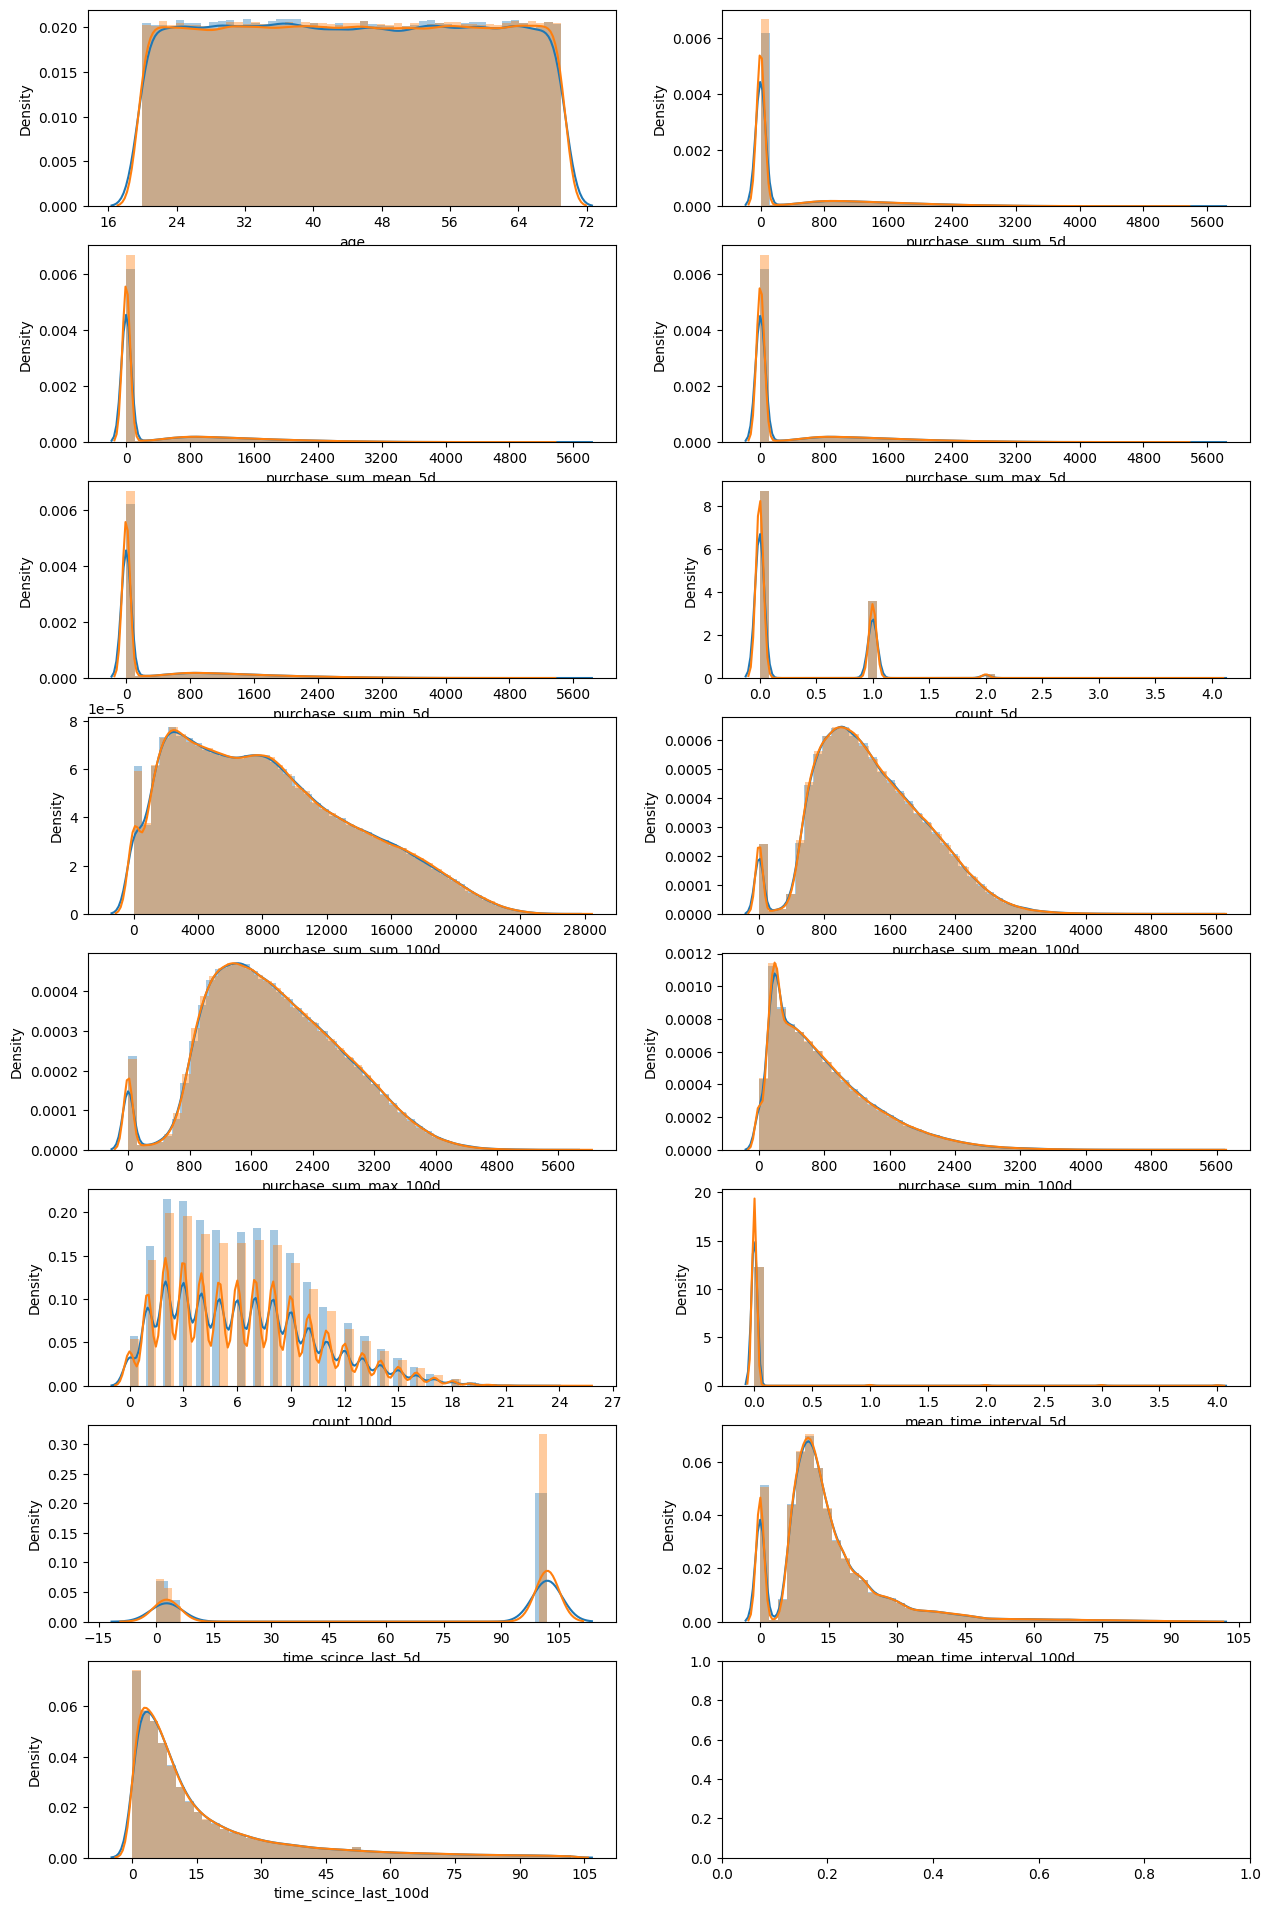

In [14]:
# show difference between treatment groups in the distribution by each feature
COLUMNS = 2
ROWS = np.ceil(len(features) / COLUMNS).astype(int)
fig, axes = plt.subplots(ROWS,COLUMNS, figsize=(15,3*ROWS))
axes = iter(np.array(axes).flatten())

for feat in features:
   ax = next(axes)
   sns.distplot(sample.loc[lambda x: x[treatment]==1, feat], ax=ax)
   sns.distplot(sample.loc[lambda x: x[treatment]==0, feat], ax=ax)
   ax.xaxis.set_major_locator(ticker.FixedLocator(ax.get_xticks()))
   ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
clear_output()
plt.show()

##### old

In [15]:
# def bins_map(splits:List[str]) -> dict:
#   # based on splits build string mapping  [0, n, n+1, n+2, ... , inf ] => {0: [0 - n), 1: [n - n + 1), ... }
#   result=dict()
#   for index in range(len(splits)-1):
#     result[index] = '[' + str(round(splits[index],1)) + ' - ' + str(round(splits[index+1],1)) + ')'
#   return result

# def feature_bucketizer(df:pyspark.sql.DataFrame, feature_col:str, enable_map:bool=False)->pyspark.sql.DataFrame:
#   # bucketize continious feature to percentiles buckets, add string mapping [n - n+1) for each bucket
#   percentiles = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
#   feature_result = feature_col + '_bins'
#   feature_result_map = feature_result + '_map'

#   splits = [0] + df.filter(f.col(feature_col) > 0).approxQuantile(feature_col, percentiles, 0.01) + [float('inf')]
#   splits = sorted(list(set(splits)))

#   bins_mapping = bins_map(splits)
#   bucketizer = Bucketizer(splits=splits, inputCol=feature_col, outputCol=feature_result)
#   df = bucketizer.transform(df)
#   if enable_map:
#     replace_grade = lambda grade: bins_mapping.get(grade, "Unknown")
#     replace_grade_udf = f.udf(replace_grade, StringType())

#     df = df.withColumn(feature_result_map, replace_grade_udf(f.col(feature_result)))

#   return df

# data = spark.read.parquet(client_features_preperiod_PATH)
# for feature in data.columns[1:]:
#   data = feature_bucketizer(data, feature, True)

# plot_features = [c for c in data.columns if '_bins' in c and '_map' not in c ]
# # add regular feature to dict (use for plotting)
# plot_features = plot_features+['age', 'location']
# plot_features

# MAX_TICKS = 12
# metric = 'revenue'
# COLUMNS = 2
# ROWS = np.ceil(len(plot_features) / COLUMNS).astype(int)
# fig, axes = plt.subplots(ROWS,COLUMNS, figsize=(13,3*ROWS))
# axes = iter(axes.flatten())

# for feature in plot_features:
#   # calculate uplift for each category in each feature
#   # mean purchase sum by each customer_id by each day
#   df_plot = (receipts_spark.filter(f.col('date').between(START_CAMPAIGN, END_CAMPAIGN + 30))
#                           #  .filter(f.col('campaign_flag') ==1)
#                            .join(data, on='customer_id', how='left')
#                            .groupby('target_group_flag', feature, 'customer_id', 'date')
#                            .agg(f.sum(metric).alias(metric))

#                            .groupby(feature).pivot('target_group_flag').agg(f.percentile_approx(metric, 0.5).alias('mean'),
#                                                                             f.percentile_approx(metric, 0.05).alias('perc_05'),
#                                                                             f.percentile_approx(metric, 0.95).alias('perc_95'),
#                                                                             )

#                            .orderBy(feature)
#                            .withColumn('uplift', f.col('1_'+'mean') - f.col('0_'+'mean'))
#                            .toPandas())
#   # plot
#   ax = next(axes)
#   sns.lineplot(data=df_plot, x=feature, y='uplift', ax=ax)
#   ax.axhline(y=0, linestyle='--', color='red',alpha=0.2)
#   ax.set_title(f"uplift by {feature} feature")
#   if df_plot[feature].nunique() > MAX_TICKS:
#     ax.xaxis.set_major_locator(ticker.MaxNLocator(MAX_TICKS))
#   if feature in {'location'}:
#     ax.xaxis.set_major_locator(ticker.FixedLocator(ax.get_xticks()))
#     ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

# plt.tight_layout()
# plt.show()

In [16]:
# df_plot = (receipts_spark.groupby('date')
#                          .agg(f.sum('revenue').alias('revenue'),
#                               f.sum('purchase_amt').alias('purchase_amt'))
#                          .orderBy('date')
#                          .toPandas())


# for metric in ['revenue', 'purchase_amt']:
#   fig, ax = plt.subplots(figsize=(10,3))
#   sns.lineplot(df_plot, x='date', y=metric, ax=ax)

#   before_campaign_metric = df_plot.loc[lambda x: x['date'] < START_CAMPAIGN][metric].mean()
#   after_campaign_metric = df_plot.loc[lambda x: x['date'] > END_CAMPAIGN][metric].mean()
#   ax.axhline(y=before_campaign_metric, linestyle='--', color='red',alpha=1, linewidth=0.5, label=f'before = {round(before_campaign_metric)}')
#   ax.axhline(y=after_campaign_metric, linestyle='--', color='green',alpha=1, linewidth=0.5, label=f'after = {round(after_campaign_metric)}')

#   ax.legend()
#   ax.set_title(f'{metric} by date')
#   plt.show()

In [17]:
# date_calcer = BackwardCalcer(target_date=START_CAMPAIGN,
#                              metrics=['date'],
#                              agg_func=['min','max', 'count'])
# client_backward_date_features = date_calcer.fit_transform(receipts_spark)
# for window in date_calcer.windows:
#   client_backward_date_features = client_backward_date_features.withColumn(f'mean_time_interval_{window}d', (f.col(f'date_max_{window}d') - f.col(f'date_min_{window}d') / f.col(f'count_{window}d')))
# client_backward_date_features.limit(10).toPandas()

In [18]:
# # bucketize continuous features
# from pyspark.ml.feature import Bucketizer
# percentiles = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# data = spark.read.parquet(str(DIR/'data'/'client_features_preperiod.parquet'))
# bins_decoder = {}
# for feature in ['purchase_sum_7d', 'purchase_sum_30d', 'purchase_sum_60d']:
#   print(feature)
#   feature_result = feature + '_bins'

#   splits = [0] + data.filter(f.col(feature) > 0).approxQuantile(feature, percentiles, 0.01)
#   bins_decoder[feature_result] = splits
#   bucketizer = Bucketizer(splits=splits, inputCol=feature, outputCol=feature_result)
#   data = bucketizer.transform(data)
# data.limit(10).toPandas()

In [19]:
# PATH = str(DIR/'data'/'purchase_extend.parquet')
# get_window = lambda PARTITIONBY, ORDERBY, WINDOW: (Window.partitionBy(PARTITIONBY)
#                                                          .orderBy(ORDERBY)
#                                                          .rangeBetween(-WINDOW, -1))

# QUERY = {}
# for col in ['purchase_amt', 'purchase_sum']:
#   for window in (7, 14, 30, 60):
#     col_name = col + '_' + str(window) + 'd'
#     QUERY[col_name] = f.avg(col).over(get_window('customer_id', f.asc('date'), window))


# (receipts_spark.withColumns(QUERY)
#                .orderBy('customer_id', 'date')
#                .fillna(0)
# )#.write.parquet(PATH, mode='overwrite')

In [20]:


# def feature_encoder(df:pyspark.sql.DataFrame, columns:list=['location'])->pyspark.sql.DataFrame:
#   def vector_to_array(v):
#       return v.toArray().tolist()
#   vector_to_array_udf = f.udf(vector_to_array, ArrayType(DoubleType()))

#   prefix_1 = '_indexer'
#   prefix_2 = '_encoder'
#   for col in columns:
#     # transform string_category to num_category
#     string_indexer = StringIndexer(inputCol=col, outputCol=col+prefix_1)
#     model = string_indexer.fit(df)
#     df = model.transform(df)
#     # get labels categories
#     categories = model.labels
#     categories = categories[: max(len(categories)-1, 1)]
#     # transform index to (0,1,0,0,0,0) sparce vector
#     one_hot_encoder = OneHotEncoder(inputCols=[col+prefix_1], outputCols=[col+prefix_2])
#     model = one_hot_encoder.fit(df)
#     df = model.transform(df)
#     # transform sparce vector to columns
#     df = df.withColumn(col+prefix_2, vector_to_array_udf(df[col+prefix_2]))
#     for i, category in enumerate(categories):
#         df = df.withColumn(f"{col}_{category}", df[col+prefix_2][i])

#     df = df.drop(col+prefix_1, col+prefix_2)

#   return df
# feature_encoder(customers_data).limit(100).toPandas()

In [21]:
# # calculate pre campaign period feature with different time depth for each  customer_id
# client_features_preperiod_PATH = str(DIR/'data'/'client_features_preperiod.parquet')

# def feature_calcer(df:pyspark.sql.DataFrame, target_date,
#                    client_col:str='customer_id',
#                    windows:list=[7,30],
#                    feutures:list=['purchase_amt', 'purchase_sum'])->pyspark.sql.DataFrame:
#   QUERY = []
#   for window in windows:
#     for feature in feutures:
#       alias = feature + '_mean_' + str(window) + 'd'
#       q = f.mean(f.when(f.col('date').between(target_date - window, target_date - 1), f.col(feature))).alias(alias)
#       QUERY.append(q)

#       alias = feature + '_sum_' + str(window) + 'd'
#       q = f.sum(f.when(f.col('date').between(target_date - window, target_date - 1), f.col(feature))).alias(alias)
#       QUERY.append(q)

#     alias = 'count_' + str(window) + 'd'
#     q = f.count(f.when(f.col('date').between(target_date - window, target_date - 1), f.col(feature))).alias(alias)
#     QUERY.append(q)

#   display(QUERY)
#   df = (df.groupby(client_col)
#           .agg(*QUERY)
#           .fillna(0))
#   return df

# feature_calcer(receipts_spark.filter(f.col('date') < START_CAMPAIGN), START_CAMPAIGN)#.write.parquet(client_features_preperiod_PATH, mode='overwrite')
# spark.read.parquet(client_features_preperiod_PATH).limit(10).toPandas()

### uplift predcition

## R-learner description:

Having understood for educational purposes how the R-learner model works by taking notes on the training materials.

1. The training dataset is divided into $Q$ folds (usually 5–10).
2. For each fold $q$, two models are built:  $μ^{(−q)}(x)$ и  $\widehat{e}^{(−q)}(x)$.

  Where $\widehat{e}$ - in our case propensity score

  $e(x) = P (T=1|X=x) $ - if flag was random => $e(x)=p$

  $CATE(x) = τ(x)=E[Y∣X=x,T=1]−E[Y∣X=x,T=0]$ - CATE (Conditional Average Treatment Effect - UPLIFT)

  $μ_t = E[Y∣X=x,T=t]$

  $X$ — user feature

  $T∈\{0,1\}$ — treatment flag.

  $Y(1)$ — the target variable in a universe where the treatment did occur

  $Y(0)$ — the target variable in a universe where the treatment did not occur

  $Y=Y(1)T+Y(0)(1−T)$ — the target variable



  Each model is trained on all folds except the selected fold $q$ (hence the minus in the index). $(X^{(−q)},Y^{(−q)})$ и $(X^{(−q)},T^{(−q)})$.

  As a result, we will have $2Q$ models. Moreover, the division into folds is independent of the division into control and target groups.
3. We build a model $\tau(x)$ to minimize the following loss function: $L_{n}(τ(x))= \frac{1}{n} ∑^n_{i=1} ((Y_i - \widehat{μ}^{(-q(i))}(X_i)) - (W_i-\widehat{e}^{(-q(i))}(X_i))τ(X_i))^2$



In [22]:
import causalml.metrics as cmetrics
from causalml.inference.meta import rlearner as learner
from lightgbm import LGBMRegressor

# init uplift model
model_learner = learner.BaseRRegressor(
    learner=LGBMRegressor(),
    control_name=0,
    n_fold=4,
)

In [23]:
# sample train data
train = sample.loc[train_mask].copy()
# calculcate p score for x learner
calc_df = train.groupby(treatment).agg({target: 'count'})
p_score = calc_df.loc[1, target] / calc_df[target].sum()
p_score_vec = pd.Series(data=p_score, index=train.index)

# fit model
model_learner.fit(X=train[features].values,
                   treatment=train[treatment].values,
                   y=train[target].values,
                   p=p_score_vec.values)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.074611 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2489
[LightGBM] [Info] Number of data points in the train set: 801420, number of used features: 15
[LightGBM] [Info] Start training from score -2.260162


In [24]:
import pickle

# save
with open('model.pkl','wb') as file:
    pickle.dump(model_learner,file)

# load
with open('model.pkl', 'rb') as file:
    model_learner = pickle.load(file)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


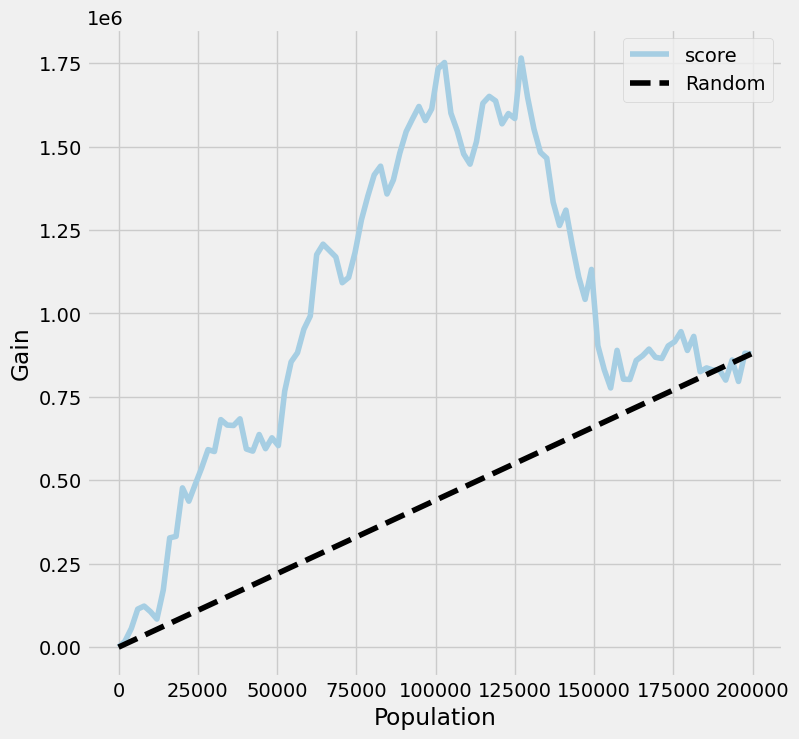

In [25]:
# sample test data
test = sample.loc[test_mask].copy()
# repeat p_score calculation for prediction
p_score_vec = pd.Series(data=p_score, index=test.index)

score = model_learner.predict(test[features], p=p_score_vec)
test['score'] = score
# plot gain find population share chose ~ 0.3-0.4
cmetrics.plot_gain(
    df=test[[target, treatment,'score']],
    outcome_col=target,
    treatment_col=treatment,
)

(-50.0, 50.0)

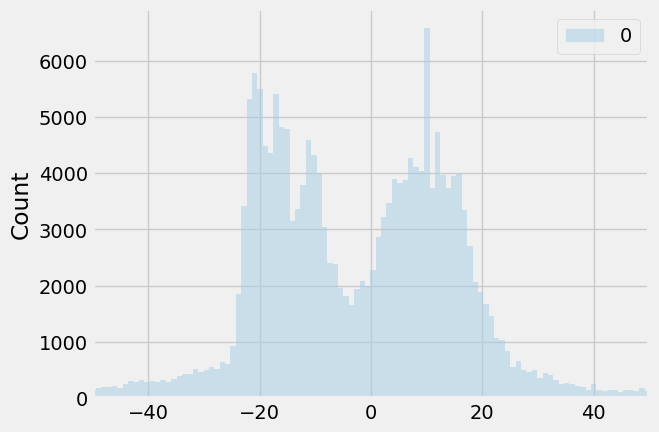

In [26]:
x_lim = 50
ax = sns.histplot(data=score)
ax.set_xlim(-x_lim, x_lim)

# Predictions

In [27]:
TARGET_DATE = receipts_spark.selectExpr("max(date)").collect()[0][0]

In [28]:
client_features_postperiod_PATH = str(DIR/'data'/'client_features_postperiod.parquet')
backward_calcer = BackwardCalcer(target_date=TARGET_DATE)
backward_calcer.fit_transform(receipts_spark).write.parquet(client_features_postperiod_PATH, mode='overwrite')
client_features = spark.read.parquet(client_features_postperiod_PATH)
client_features.limit(10).toPandas()

[Column<'sum(CASE WHEN ((date >= 244) AND (date <= 249)) THEN purchase_sum END) AS purchase_sum_sum_5d'>,
 Column<'avg(CASE WHEN ((date >= 244) AND (date <= 249)) THEN purchase_sum END) AS purchase_sum_mean_5d'>,
 Column<'max(CASE WHEN ((date >= 244) AND (date <= 249)) THEN purchase_sum END) AS purchase_sum_max_5d'>,
 Column<'min(CASE WHEN ((date >= 244) AND (date <= 249)) THEN purchase_sum END) AS purchase_sum_min_5d'>,
 Column<'max(CASE WHEN ((date >= 244) AND (date <= 249)) THEN date END) AS date_max_5d'>,
 Column<'min(CASE WHEN ((date >= 244) AND (date <= 249)) THEN date END) AS date_min_5d'>,
 Column<'count(CASE WHEN ((date >= 244) AND (date <= 249)) THEN date END) AS count_5d'>,
 Column<'sum(CASE WHEN ((date >= 149) AND (date <= 249)) THEN purchase_sum END) AS purchase_sum_sum_100d'>,
 Column<'avg(CASE WHEN ((date >= 149) AND (date <= 249)) THEN purchase_sum END) AS purchase_sum_mean_100d'>,
 Column<'max(CASE WHEN ((date >= 149) AND (date <= 249)) THEN purchase_sum END) AS purcha

,customer_id,purchase_sum_sum_5d,purchase_sum_mean_5d,purchase_sum_max_5d,purchase_sum_min_5d,date_max_5d,date_min_5d,count_5d,purchase_sum_sum_100d,purchase_sum_mean_100d,purchase_sum_max_100d,purchase_sum_min_100d,date_max_100d,date_min_100d,count_100d,mean_time_interval_5d,time_scince_last_5d,mean_time_interval_100d,time_scince_last_100d
0,2,2745.2485,2745.2485,2745.2485,2745.2485,246,246,1,18948.2725,2706.8961,3454.7351,1940.5610,246,172,7,NaN,3,12.3333,3
1,8,0.0000,0.0000,0.0000,0.0000,0,0,0,19512.2259,2439.0282,3877.1463,222.6358,243,149,8,-0.0000,249,13.4286,6
2,11,0.0000,0.0000,0.0000,0.0000,0,0,0,11142.4117,1392.8015,2015.5544,623.0536,243,155,8,-0.0000,249,12.5714,6
3,35,0.0000,0.0000,0.0000,0.0000,0,0,0,3795.1391,948.7848,1472.8213,550.6765,231,182,4,-0.0000,249,16.3333,18
4,49,0.0000,0.0000,0.0000,0.0000,0,0,0,5123.3476,1707.7825,2929.2378,192.8099,236,193,3,-0.0000,249,21.5000,13
5,62,0.0000,0.0000,0.0000,0.0000,0,0,0,609.4245,609.4245,609.4245,609.4245,241,241,1,-0.0000,249,NaN,8
6,66,973.5342,973.5342,973.5342,973.5342,244,244,1,12234.0157,941.0781,1522.8851,189.7436,244,156,13,NaN,5,7.3333,5
7,74,1713.2085,1713.2085,1713.2085,1713.2085,244,244,1,9193.2866,1149.1608,1713.2085,323.1225,244,164,8,NaN,5,11.4286,5
8,76,0.0000,0.0000,0.0000,0.0000,0,0,0,17404.9854,2175.6232,3464.2322,1349.8882,239,155,8,-0.0000,249,12.0000,10
9,80,1329.8104,1329.8104,1329.8104,1329.8104,244,244,1,3221.9969,805.4992,1329.8104,240.8240,244,156,4,NaN,5,29.3333,5


In [29]:
forecast_data = customers_spark.join(client_features, on=['customer_id'], how='left').fillna(0)
forecast_data = onehotencoder.transform(forecast_data)
forecast = forecast_data.toPandas()
forecast.head(4)

,customer_id,age,location,purchase_sum_sum_5d,purchase_sum_mean_5d,purchase_sum_max_5d,purchase_sum_min_5d,date_max_5d,date_min_5d,count_5d,purchase_sum_sum_100d,purchase_sum_mean_100d,purchase_sum_max_100d,purchase_sum_min_100d,date_max_100d,date_min_100d,count_100d,mean_time_interval_5d,time_scince_last_5d,mean_time_interval_100d,time_scince_last_100d,location_Novigrad,location_Beauclair,location_Oxenfurt,location_Spikeroog,location_Hindarsfjall,location_Kaer_Trolde
0,0,56,Oxenfurt,0.0000,0.0000,0.0000,0.0000,0,0,0,8598.8142,781.7104,1371.0855,259.8679,241,154,11,-0.0000,249,8.7000,8,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
1,1,53,Hindarsfjall,841.4023,841.4023,841.4023,841.4023,245,245,1,4714.9482,942.9896,1156.7440,676.3395,245,157,5,0.0000,4,22.0000,4,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
2,5,27,Spikeroog,0.0000,0.0000,0.0000,0.0000,0,0,0,9364.4044,1560.7341,2314.5161,539.7359,223,163,6,-0.0000,249,12.0000,26,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
3,6,57,Hindarsfjall,949.0280,949.0280,949.0280,949.0280,245,245,1,8372.7807,930.3090,1429.9434,478.9448,245,149,9,0.0000,4,12.0000,4,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(-100.0, 100.0)

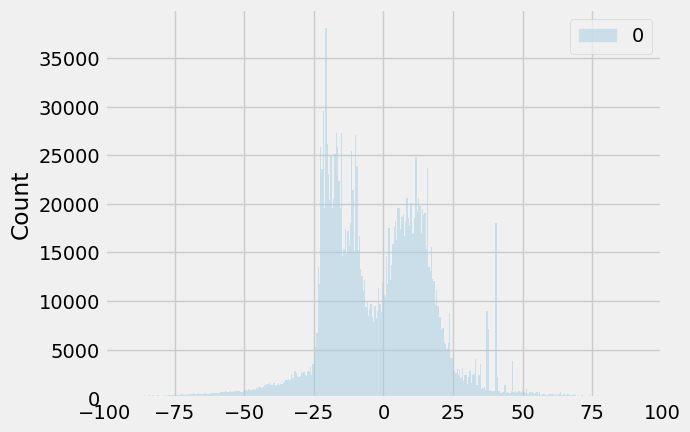

In [30]:
# calculcate p score for x learner
p_score_vec = pd.Series(data=p_score, index=forecast.index)

score = model_learner.predict(forecast[features], p=p_score_vec)
forecast['score'] = score

# show score distribution
x_lim = 100
ax = sns.histplot(data=score)
ax.set_xlim(-x_lim, x_lim)

In [31]:
TRESHOLD = 5
(forecast['score'] > TRESHOLD).mean()

np.float64(0.395417)

In [32]:
# save result to load in a training system
(forecast.loc[lambda x: x['score'] > TRESHOLD]
         ['customer_id']
         .to_csv(str(DIR/'data'/'forecast.csv'), index=False)
)

**Criteria used by the evaluation system**

```
revenue = (
    (
        (revenue_in_target_group - cost_price_in_target_group) / target_group_size -
        (revenue_in_control_group - cost_price_in_control_group) / control_group_size
    ) * target_group_size
    - discount_sum - message_delivery_sum
) * (
    (target_group_size + control_group_size) / target_group_size
)
```

In [ ]:
# our campaign earn more than 4_500_000 orens